# Análise Exploratória do Conjunto de Treino

## Importar bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Análise de notas e faltas

Dataset EDA carregado, total de alunos: 207


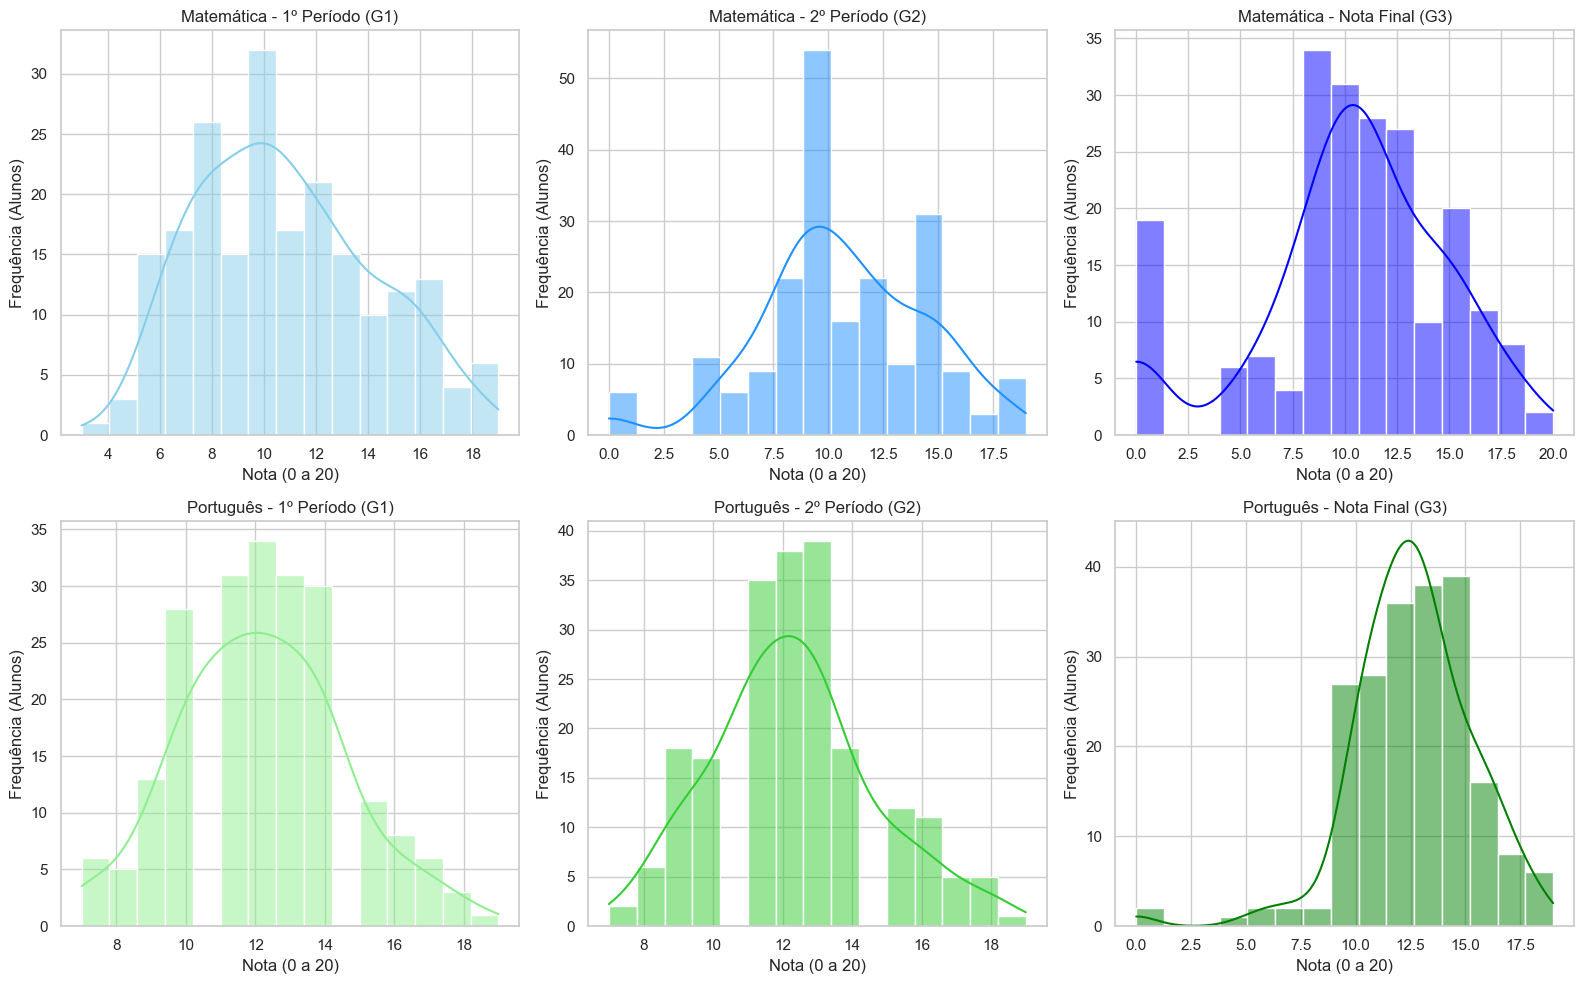

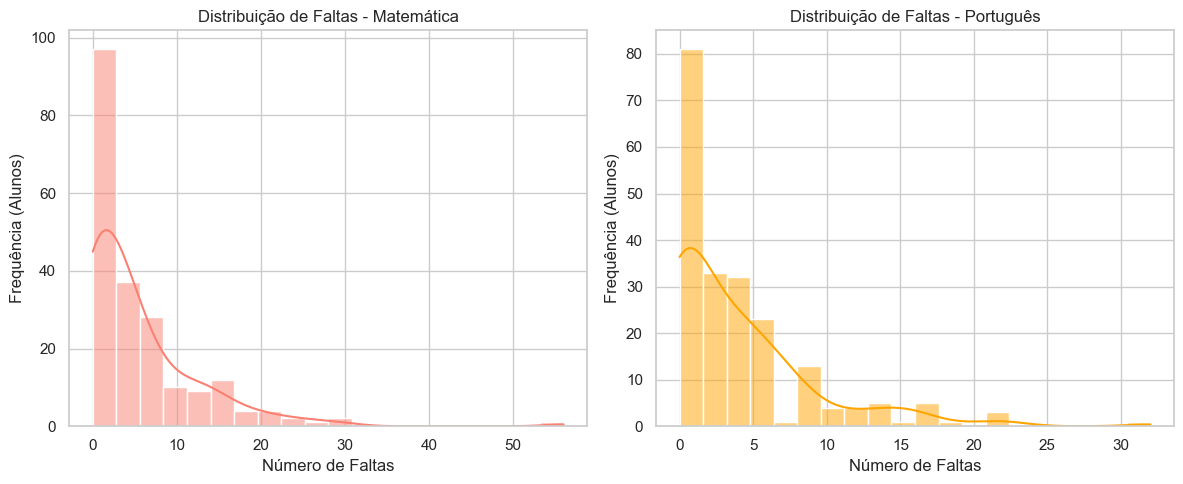

ESTATÍSTICAS DESCRITIVAS: NOTAS E FALTAS (CONJUNTO EDA)
            Média  Moda  Mediana  Desvio Padrão  Mínimo  Máximo
NOTA_1_MAT  10.77    10    10.00           3.32    3.00   19.00
NOTA_2_MAT  10.66    10    10.00           3.77    0.00   19.00
NOTA_3_MAT  10.35    10    11.00           4.55    0.00   20.00
NOTA_1_POR  12.17    12    12.00           2.38    7.00   19.00
NOTA_2_POR  12.29    13    12.00           2.36    7.00   19.00
NOTA_3_POR  12.61    13    13.00           2.72    0.00   19.00
FALTAS_MAT   5.49     0     4.00           7.16    0.00   56.00
FALTAS_POR   3.93     0     2.00           5.11    0.00   32.00


In [2]:
# Carregar dataset EDA da pasta dataset
df_eda = pd.read_csv("../dataset/student-eda.csv")

print(f"Dataset EDA carregado, total de alunos: {len(df_eda)}")

# Configuração de estilo visual para todos os gráficos do notebook
sns.set_theme(style="whitegrid")

# Gráfico de distribuição das notas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Linha 1: Matemática
sns.histplot(df_eda['NOTA_1_MAT'], bins=15, kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Matemática - 1º Período (G1)')

sns.histplot(df_eda['NOTA_2_MAT'], bins=15, kde=True, color='dodgerblue', ax=axes[0, 1])
axes[0, 1].set_title('Matemática - 2º Período (G2)')

sns.histplot(df_eda['NOTA_3_MAT'], bins=15, kde=True, color='blue', ax=axes[0, 2])
axes[0, 2].set_title('Matemática - Nota Final (G3)')

# Linha 2: Português
sns.histplot(df_eda['NOTA_1_POR'], bins=15, kde=True, color='lightgreen', ax=axes[1, 0])
axes[1, 0].set_title('Português - 1º Período (G1)')

sns.histplot(df_eda['NOTA_2_POR'], bins=15, kde=True, color='limegreen', ax=axes[1, 1])
axes[1, 1].set_title('Português - 2º Período (G2)')

sns.histplot(df_eda['NOTA_3_POR'], bins=15, kde=True, color='green', ax=axes[1, 2])
axes[1, 2].set_title('Português - Nota Final (G3)')

# Ajustando rótulos para todos os 6 gráficos
for ax in axes.flat:
    ax.set_ylabel('Frequência (Alunos)')
    ax.set_xlabel('Nota (0 a 20)')
    ax.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

# Gráfico de Distribuição de faltas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Faltas Matemática
sns.histplot(df_eda['FALTAS_MAT'], bins=20, kde=True, color='salmon', ax=axes[0])
axes[0].set_title('Distribuição de Faltas - Matemática')
axes[0].set_xlabel('Número de Faltas')

# Faltas Português
sns.histplot(df_eda['FALTAS_POR'], bins=20, kde=True, color='orange', ax=axes[1])
axes[1].set_title('Distribuição de Faltas - Português')
axes[1].set_xlabel('Número de Faltas')

# Formatando os eixos das faltas
for ax in axes:
    ax.set_ylabel('Frequência (Alunos)')
    ax.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()


# Impressão das informações
# Colunas usadas nos gráficos
colunas_analise = [
    'NOTA_1_MAT', 'NOTA_2_MAT', 'NOTA_3_MAT',
    'NOTA_1_POR', 'NOTA_2_POR', 'NOTA_3_POR',
    'FALTAS_MAT', 'FALTAS_POR'
]

# Calcula as estatísticas básicas
estatisticas = df_eda[colunas_analise].describe().T

# Adiciona a Moda (o valor mais frequente)
estatisticas['moda'] = df_eda[colunas_analise].mode().iloc[0]

# Reorganizando a ordem das colunas
ordem_colunas = ['mean', 'moda', '50%', 'std', 'min', 'max']
estatisticas = estatisticas[ordem_colunas]

# Renomeando as colunas
estatisticas.columns = ['Média', 'Moda', 'Mediana', 'Desvio Padrão', 'Mínimo', 'Máximo']

# Formatando para exibir apenas duas casas decimais
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("="*80)
print("ESTATÍSTICAS DESCRITIVAS: NOTAS E FALTAS (CONJUNTO EDA)")
print("="*80)
print(estatisticas)
print("="*80)

## Estatísticas descritivas das variáveis categóricas

In [3]:
# Variáveis categóricas nominais
cat_nominais = ['SEXO', 'NOME_ESCOLA', 'RAZAO_ESCOLHA_ESCOLA', 'RESPONSAVEL',
                'STATUS_PAIS', 'PROFISSAO_MAE', 'PROFISSAO_PAI', 'TAMANHO_FAMILIA',
                'TIPO_ENDERECO']

# Variáveis categóricas binárias (True/False)
cat_binarias = ['CRECHE', 'ALMEJA_ENSINO_SUPERIOR', 'SUPORTE_ESCOLAR',
                'SUPORTE_FAMILIAR', 'INTERNET_CASA', 'ATIVIDADES_EXTRAS',
                'RELACIONAMENTO', 'AULAS_PAGAS_MAT', 'AULAS_PAGAS_POR']

# Variáveis ordinais
cat_ordinais = ['ESCOLARIDADE_MAE', 'ESCOLARIDADE_PAI', 'TEMPO_ESTUDO_SEMANAL',
                'TEMPO_DESLOCAMENTO', 'QUALIDADE_FAMILA', 'TEMPO_LIVRE',
                'SAIR_COM_AMIGOS', 'ALCOOL_DIA_UTIL', 'ALCOOL_FIM_DE_SEMANA', 'SAUDE']

print("="*80)
print("DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS NOMINAIS")
print("="*80)
for col in cat_nominais:
    print(f"\n--- {col} ---")
    contagem = df_eda[col].value_counts()
    percentual = df_eda[col].value_counts(normalize=True) * 100
    resumo = pd.DataFrame({'Contagem': contagem, '%': percentual.round(1)})
    print(resumo)

print("\n" + "="*80)
print("DISTRIBUIÇÃO DAS VARIÁVEIS BINÁRIAS")
print("="*80)
for col in cat_binarias:
    contagem = df_eda[col].value_counts()
    print(f"{col}: True={contagem.get(True, 0)} ({contagem.get(True, 0)/len(df_eda)*100:.1f}%) | False={contagem.get(False, 0)} ({contagem.get(False, 0)/len(df_eda)*100:.1f}%)")

print("\n" + "="*80)
print("DISTRIBUIÇÃO DAS VARIÁVEIS ORDINAIS")
print("="*80)
for col in cat_ordinais:
    print(f"\n--- {col} ---")
    contagem = df_eda[col].value_counts().sort_index()
    percentual = df_eda[col].value_counts(normalize=True).sort_index() * 100
    resumo = pd.DataFrame({'Contagem': contagem, '%': percentual.round(1)})
    print(resumo)

DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS NOMINAIS

--- SEXO ---
           Contagem     %
SEXO                     
feminino        110 53.10
masculino        97 46.90

--- NOME_ESCOLA ---
                      Contagem     %
NOME_ESCOLA                         
Gabriel Pereira            187 90.30
Mousinho da Silveira        20  9.70

--- RAZAO_ESCOLHA_ESCOLA ---
                      Contagem     %
RAZAO_ESCOLHA_ESCOLA                
curso                       78 37.70
proximo_casa                58 28.00
reputacao                   54 26.10
outro                       17  8.20

--- RESPONSAVEL ---
             Contagem     %
RESPONSAVEL                
mae               141 68.10
pai                54 26.10
outro              12  5.80

--- STATUS_PAIS ---
             Contagem     %
STATUS_PAIS                
juntos            184 88.90
separados          23 11.10

--- PROFISSAO_MAE ---
               Contagem     %
PROFISSAO_MAE                
outro                79 38.20
servic

## Curadoria dos dados: dados faltantes, outliers e inconsistências

In [4]:
import numpy as np

print("="*80)
print("ANÁLISE DE DADOS FALTANTES")
print("="*80)
faltantes = df_eda.isnull().sum()
print(f"Total de valores faltantes por coluna:")
print(faltantes[faltantes > 0] if faltantes.sum() > 0 else "Nenhum valor faltante encontrado.")
print(f"\nTotal geral de valores faltantes: {faltantes.sum()}")

print("\n" + "="*80)
print("ANÁLISE DE OUTLIERS (Método IQR) - Variáveis Quantitativas")
print("="*80)
vars_quantitativas = ['IDADE', 'FALTAS_MAT', 'FALTAS_POR',
                      'NOTA_1_MAT', 'NOTA_2_MAT', 'NOTA_3_MAT',
                      'NOTA_1_POR', 'NOTA_2_POR', 'NOTA_3_POR']

for col in vars_quantitativas:
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_eda[(df_eda[col] < lower) | (df_eda[col] > upper)]
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers (limites: [{lower:.1f}, {upper:.1f}])")
    else:
        print(f"{col}: Sem outliers")

print("\n" + "="*80)
print("ANÁLISE DE INCONSISTÊNCIAS")
print("="*80)
# Notas zero (possível abandono)
zeros_mat = (df_eda['NOTA_3_MAT'] == 0).sum()
zeros_por = (df_eda['NOTA_3_POR'] == 0).sum()
print(f"Alunos com nota final 0 em Matemática: {zeros_mat} ({zeros_mat/len(df_eda)*100:.1f}%)")
print(f"Alunos com nota final 0 em Português: {zeros_por} ({zeros_por/len(df_eda)*100:.1f}%)")
print(f"\nNota: Notas zero podem indicar abandono ou não comparecimento às avaliações.")
print(f"Decisão: Manter esses registros pois representam um perfil real de aluno.")

ANÁLISE DE DADOS FALTANTES
Total de valores faltantes por coluna:
Nenhum valor faltante encontrado.

Total geral de valores faltantes: 0

ANÁLISE DE OUTLIERS (Método IQR) - Variáveis Quantitativas
IDADE: 9 outliers (limites: [14.5, 18.5])
FALTAS_MAT: 8 outliers (limites: [-12.0, 20.0])
FALTAS_POR: 10 outliers (limites: [-9.0, 15.0])
NOTA_1_MAT: Sem outliers
NOTA_2_MAT: 6 outliers (limites: [0.5, 20.5])
NOTA_3_MAT: 19 outliers (limites: [0.5, 20.5])
NOTA_1_POR: Sem outliers
NOTA_2_POR: 8 outliers (limites: [7.2, 17.2])
NOTA_3_POR: 6 outliers (limites: [6.5, 18.5])

ANÁLISE DE INCONSISTÊNCIAS
Alunos com nota final 0 em Matemática: 19 (9.2%)
Alunos com nota final 0 em Português: 2 (1.0%)

Nota: Notas zero podem indicar abandono ou não comparecimento às avaliações.
Decisão: Manter esses registros pois representam um perfil real de aluno.


## Boxplots: Variáveis categóricas vs Notas finais

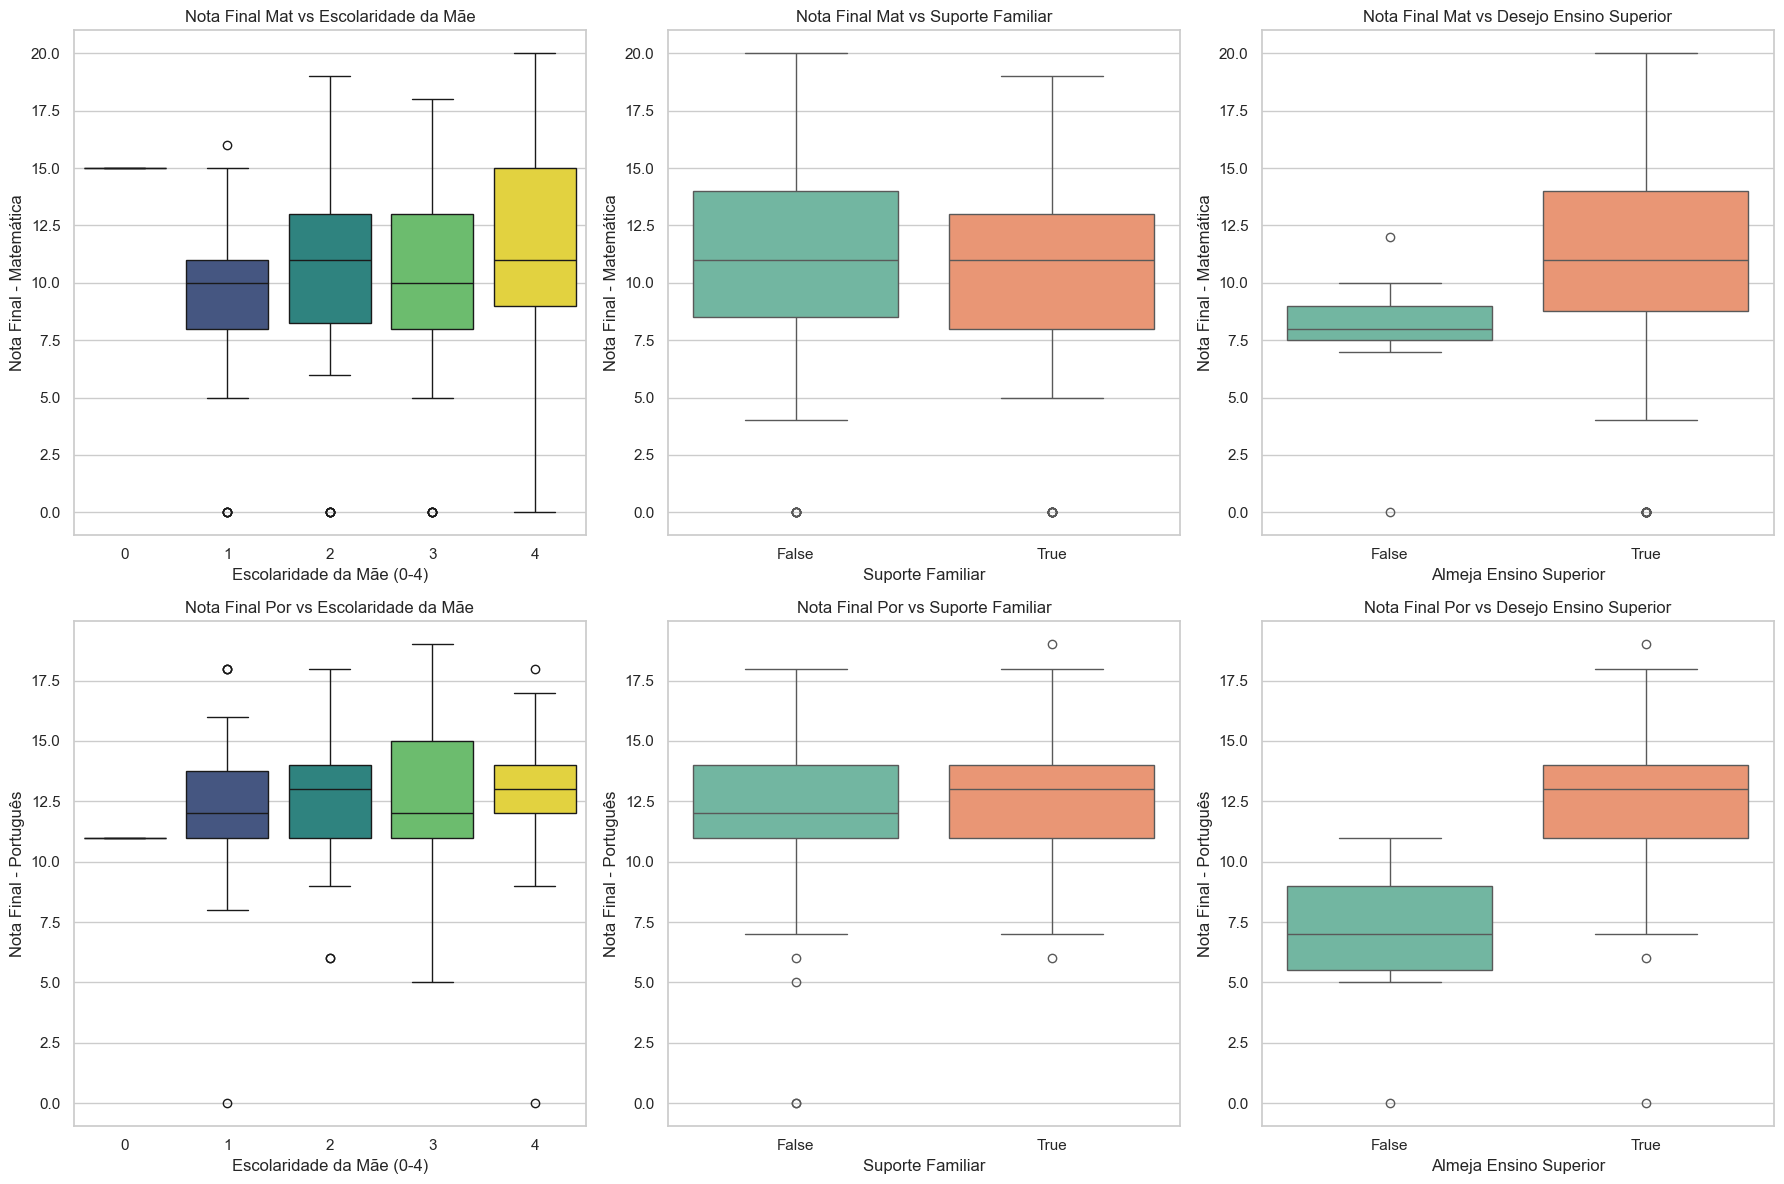

In [5]:
# Boxplots: Nota final de Matemática (G3) vs variáveis categóricas relevantes
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

sns.boxplot(x='ESCOLARIDADE_MAE', y='NOTA_3_MAT', hue='ESCOLARIDADE_MAE', data=df_eda, ax=axes[0, 0], palette='viridis', legend=False)
axes[0, 0].set_title('Nota Final Mat vs Escolaridade da Mãe')
axes[0, 0].set_xlabel('Escolaridade da Mãe (0-4)')
axes[0, 0].set_ylabel('Nota Final - Matemática')

sns.boxplot(x='SUPORTE_FAMILIAR', y='NOTA_3_MAT', hue='SUPORTE_FAMILIAR', data=df_eda, ax=axes[0, 1], palette='Set2', legend=False)
axes[0, 1].set_title('Nota Final Mat vs Suporte Familiar')
axes[0, 1].set_xlabel('Suporte Familiar')
axes[0, 1].set_ylabel('Nota Final - Matemática')

sns.boxplot(x='ALMEJA_ENSINO_SUPERIOR', y='NOTA_3_MAT', hue='ALMEJA_ENSINO_SUPERIOR', data=df_eda, ax=axes[0, 2], palette='Set2', legend=False)
axes[0, 2].set_title('Nota Final Mat vs Desejo Ensino Superior')
axes[0, 2].set_xlabel('Almeja Ensino Superior')
axes[0, 2].set_ylabel('Nota Final - Matemática')

sns.boxplot(x='ESCOLARIDADE_MAE', y='NOTA_3_POR', hue='ESCOLARIDADE_MAE', data=df_eda, ax=axes[1, 0], palette='viridis', legend=False)
axes[1, 0].set_title('Nota Final Por vs Escolaridade da Mãe')
axes[1, 0].set_xlabel('Escolaridade da Mãe (0-4)')
axes[1, 0].set_ylabel('Nota Final - Português')

sns.boxplot(x='SUPORTE_FAMILIAR', y='NOTA_3_POR', hue='SUPORTE_FAMILIAR', data=df_eda, ax=axes[1, 1], palette='Set2', legend=False)
axes[1, 1].set_title('Nota Final Por vs Suporte Familiar')
axes[1, 1].set_xlabel('Suporte Familiar')
axes[1, 1].set_ylabel('Nota Final - Português')

sns.boxplot(x='ALMEJA_ENSINO_SUPERIOR', y='NOTA_3_POR', hue='ALMEJA_ENSINO_SUPERIOR', data=df_eda, ax=axes[1, 2], palette='Set2', legend=False)
axes[1, 2].set_title('Nota Final Por vs Desejo Ensino Superior')
axes[1, 2].set_xlabel('Almeja Ensino Superior')
axes[1, 2].set_ylabel('Nota Final - Português')

plt.tight_layout()
plt.show()

## Gráficos de dispersão

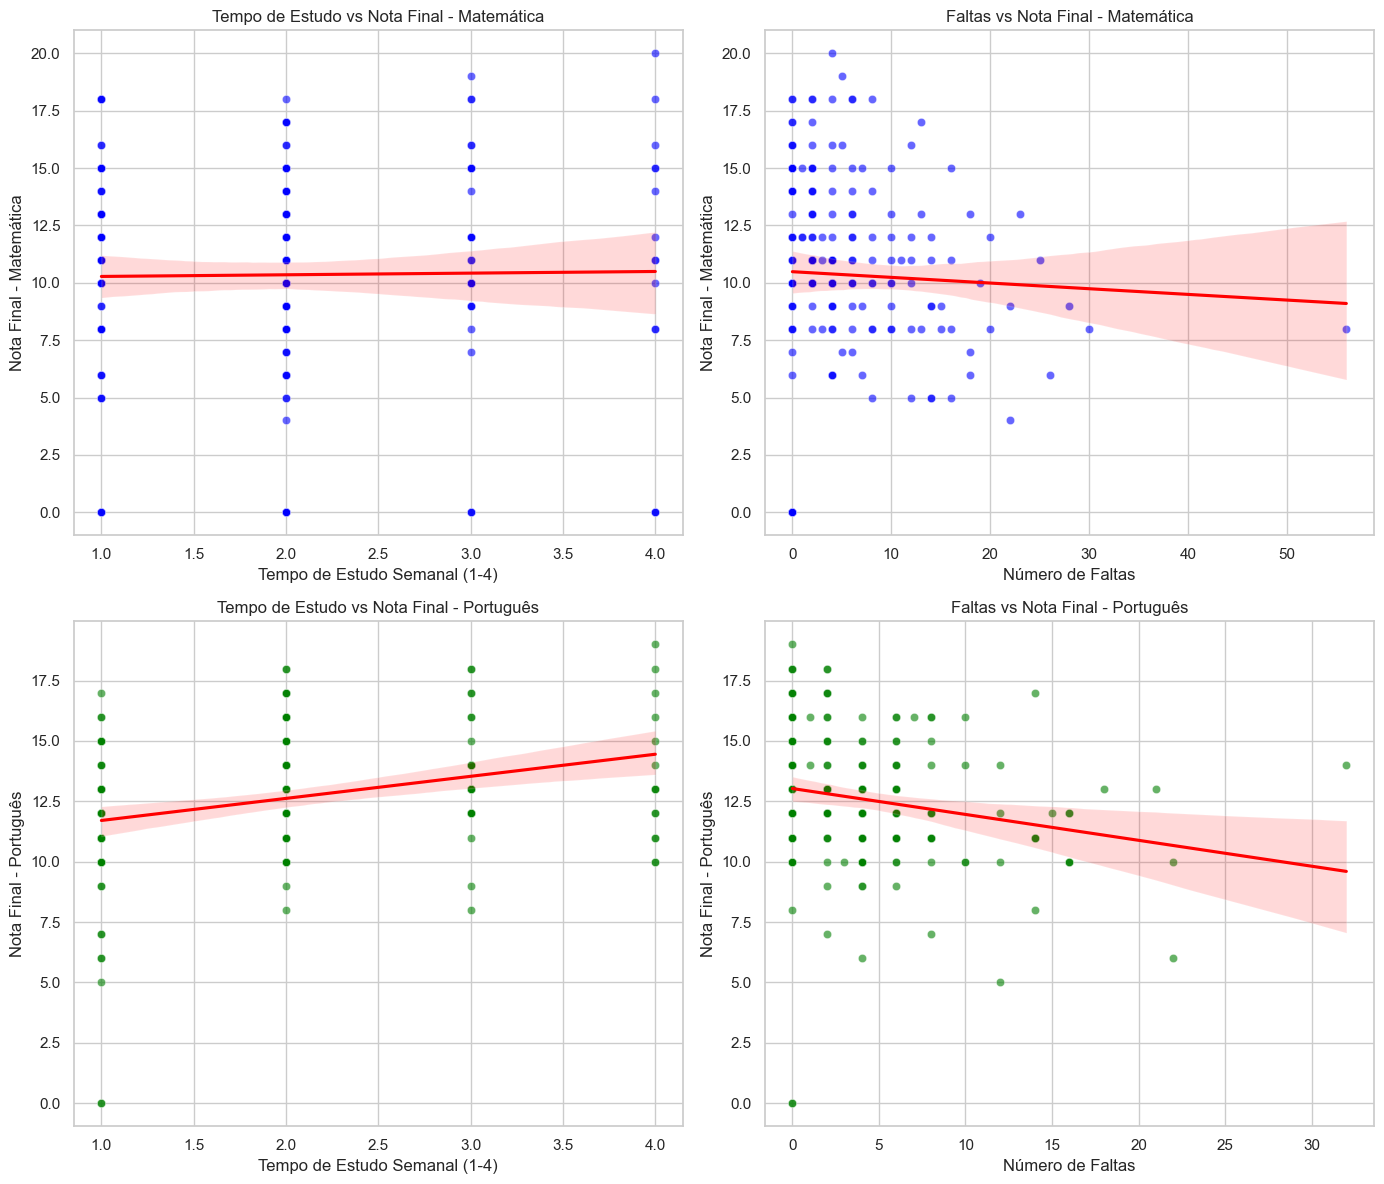

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Tempo de estudo vs Nota final Matemática
sns.scatterplot(x='TEMPO_ESTUDO_SEMANAL', y='NOTA_3_MAT', data=df_eda, ax=axes[0, 0], alpha=0.6, color='blue')
sns.regplot(x='TEMPO_ESTUDO_SEMANAL', y='NOTA_3_MAT', data=df_eda, ax=axes[0, 0], scatter=False, color='red')
axes[0, 0].set_title('Tempo de Estudo vs Nota Final - Matemática')
axes[0, 0].set_xlabel('Tempo de Estudo Semanal (1-4)')
axes[0, 0].set_ylabel('Nota Final - Matemática')

# Faltas vs Nota final Matemática
sns.scatterplot(x='FALTAS_MAT', y='NOTA_3_MAT', data=df_eda, ax=axes[0, 1], alpha=0.6, color='blue')
sns.regplot(x='FALTAS_MAT', y='NOTA_3_MAT', data=df_eda, ax=axes[0, 1], scatter=False, color='red')
axes[0, 1].set_title('Faltas vs Nota Final - Matemática')
axes[0, 1].set_xlabel('Número de Faltas')
axes[0, 1].set_ylabel('Nota Final - Matemática')

# Tempo de estudo vs Nota final Português
sns.scatterplot(x='TEMPO_ESTUDO_SEMANAL', y='NOTA_3_POR', data=df_eda, ax=axes[1, 0], alpha=0.6, color='green')
sns.regplot(x='TEMPO_ESTUDO_SEMANAL', y='NOTA_3_POR', data=df_eda, ax=axes[1, 0], scatter=False, color='red')
axes[1, 0].set_title('Tempo de Estudo vs Nota Final - Português')
axes[1, 0].set_xlabel('Tempo de Estudo Semanal (1-4)')
axes[1, 0].set_ylabel('Nota Final - Português')

# Faltas vs Nota final Português
sns.scatterplot(x='FALTAS_POR', y='NOTA_3_POR', data=df_eda, ax=axes[1, 1], alpha=0.6, color='green')
sns.regplot(x='FALTAS_POR', y='NOTA_3_POR', data=df_eda, ax=axes[1, 1], scatter=False, color='red')
axes[1, 1].set_title('Faltas vs Nota Final - Português')
axes[1, 1].set_xlabel('Número de Faltas')
axes[1, 1].set_ylabel('Nota Final - Português')

plt.tight_layout()
plt.show()

## Matriz de correlação entre variáveis numéricas

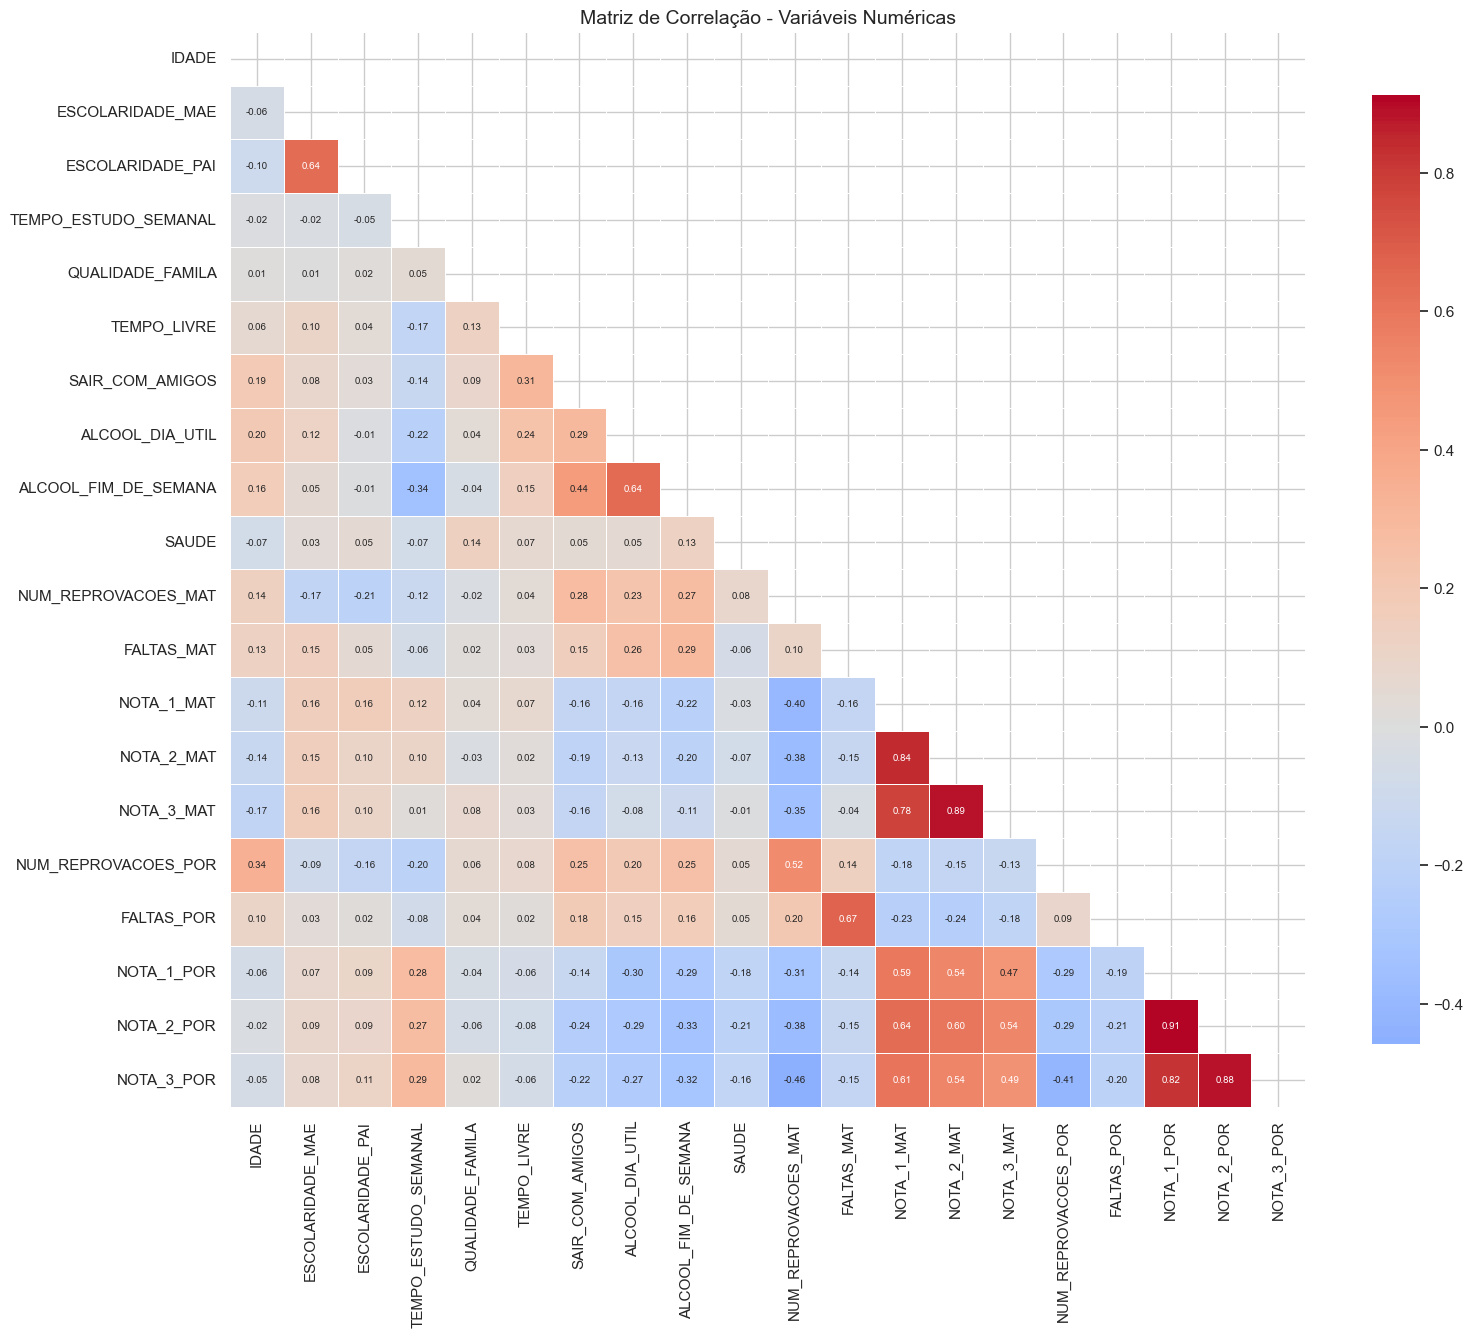


CORRELAÇÕES MAIS FORTES COM NOTA FINAL DE MATEMÁTICA (G3)
NOTA_2_MAT             0.89
NOTA_1_MAT             0.78
NOTA_2_POR             0.54
NOTA_3_POR             0.49
NOTA_1_POR             0.47
NUM_REPROVACOES_MAT   -0.35
FALTAS_POR            -0.18
IDADE                 -0.17
ESCOLARIDADE_MAE       0.16
SAIR_COM_AMIGOS       -0.16
Name: NOTA_3_MAT, dtype: float64

CORRELAÇÕES MAIS FORTES COM NOTA FINAL DE PORTUGUÊS (G3)
NOTA_2_POR              0.88
NOTA_1_POR              0.82
NOTA_1_MAT              0.61
NOTA_2_MAT              0.54
NOTA_3_MAT              0.49
NUM_REPROVACOES_MAT    -0.46
NUM_REPROVACOES_POR    -0.41
ALCOOL_FIM_DE_SEMANA   -0.32
TEMPO_ESTUDO_SEMANAL    0.29
ALCOOL_DIA_UTIL        -0.27
Name: NOTA_3_POR, dtype: float64


In [7]:
# Selecionar variáveis numéricas para correlação
vars_corr = ['IDADE', 'ESCOLARIDADE_MAE', 'ESCOLARIDADE_PAI',
             'TEMPO_ESTUDO_SEMANAL', 'QUALIDADE_FAMILA', 'TEMPO_LIVRE',
             'SAIR_COM_AMIGOS', 'ALCOOL_DIA_UTIL', 'ALCOOL_FIM_DE_SEMANA',
             'SAUDE', 'NUM_REPROVACOES_MAT', 'FALTAS_MAT',
             'NOTA_1_MAT', 'NOTA_2_MAT', 'NOTA_3_MAT',
             'NUM_REPROVACOES_POR', 'FALTAS_POR',
             'NOTA_1_POR', 'NOTA_2_POR', 'NOTA_3_POR']

corr_matrix = df_eda[vars_corr].corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
plt.title('Matriz de Correlação - Variáveis Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

# Correlações mais fortes com as notas finais
print("\n" + "="*80)
print("CORRELAÇÕES MAIS FORTES COM NOTA FINAL DE MATEMÁTICA (G3)")
print("="*80)
corr_mat = corr_matrix['NOTA_3_MAT'].drop('NOTA_3_MAT').sort_values(key=abs, ascending=False)
print(corr_mat.head(10))

print("\n" + "="*80)
print("CORRELAÇÕES MAIS FORTES COM NOTA FINAL DE PORTUGUÊS (G3)")
print("="*80)
corr_por = corr_matrix['NOTA_3_POR'].drop('NOTA_3_POR').sort_values(key=abs, ascending=False)
print(corr_por.head(10))

---
## Análise das Questões Secundárias (EP1)
---

### Q1: O impacto das faltas e do histórico de reprovações indica mais prejuízo em Matemática do que em Português?

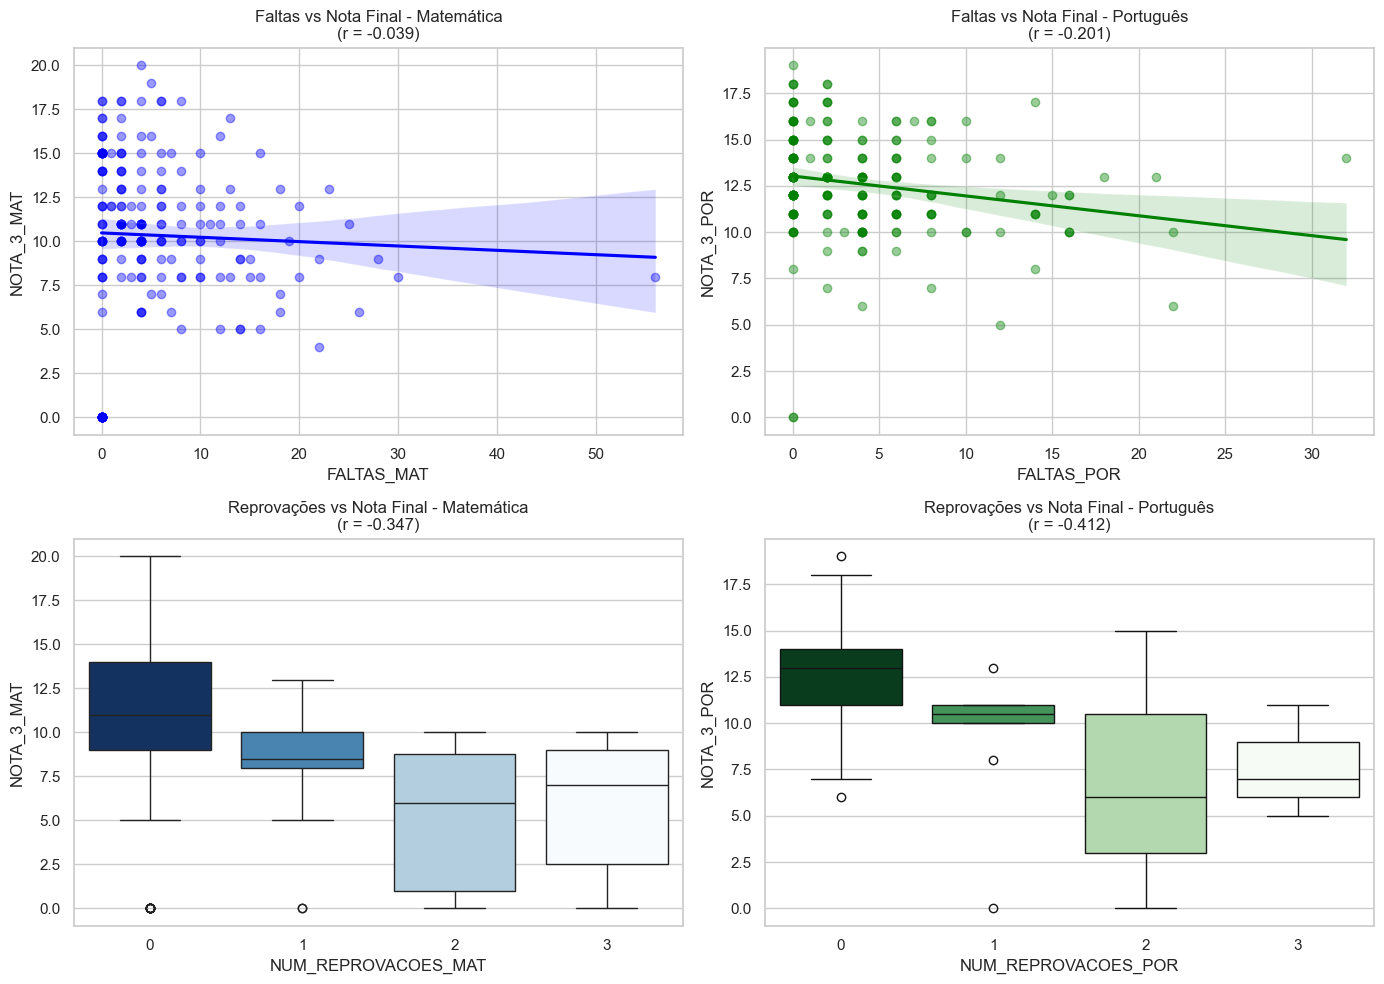


Comparação das correlações:
  Faltas → Nota Final:      Mat r=-0.039  |  Por r=-0.201
  Reprovações → Nota Final:  Mat r=-0.347  |  Por r=-0.412


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Faltas vs Nota final
sns.regplot(x='FALTAS_MAT', y='NOTA_3_MAT', data=df_eda, ax=axes[0, 0], scatter_kws={'alpha':0.4}, color='blue')
axes[0, 0].set_title(f"Faltas vs Nota Final - Matemática\n(r = {df_eda['FALTAS_MAT'].corr(df_eda['NOTA_3_MAT']):.3f})")

sns.regplot(x='FALTAS_POR', y='NOTA_3_POR', data=df_eda, ax=axes[0, 1], scatter_kws={'alpha':0.4}, color='green')
axes[0, 1].set_title(f"Faltas vs Nota Final - Português\n(r = {df_eda['FALTAS_POR'].corr(df_eda['NOTA_3_POR']):.3f})")

# Reprovações vs Nota final
sns.boxplot(x='NUM_REPROVACOES_MAT', y='NOTA_3_MAT', hue='NUM_REPROVACOES_MAT', data=df_eda, ax=axes[1, 0], palette='Blues_r', legend=False)
axes[1, 0].set_title(f"Reprovações vs Nota Final - Matemática\n(r = {df_eda['NUM_REPROVACOES_MAT'].corr(df_eda['NOTA_3_MAT']):.3f})")

sns.boxplot(x='NUM_REPROVACOES_POR', y='NOTA_3_POR', hue='NUM_REPROVACOES_POR', data=df_eda, ax=axes[1, 1], palette='Greens_r', legend=False)
axes[1, 1].set_title(f"Reprovações vs Nota Final - Português\n(r = {df_eda['NUM_REPROVACOES_POR'].corr(df_eda['NOTA_3_POR']):.3f})")

plt.tight_layout()
plt.show()

print("\nComparação das correlações:")
print(f"  Faltas → Nota Final:      Mat r={df_eda['FALTAS_MAT'].corr(df_eda['NOTA_3_MAT']):.3f}  |  Por r={df_eda['FALTAS_POR'].corr(df_eda['NOTA_3_POR']):.3f}")
print(f"  Reprovações → Nota Final:  Mat r={df_eda['NUM_REPROVACOES_MAT'].corr(df_eda['NOTA_3_MAT']):.3f}  |  Por r={df_eda['NUM_REPROVACOES_POR'].corr(df_eda['NOTA_3_POR']):.3f}")

### Q2: O desejo de fazer ensino superior afeta consideravelmente as notas finais?

/var/folders/zf/qp_b0mvj0d1gww4wj9pz7r440000gq/T/ipykernel_78234/1311215161.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='ALMEJA_ENSINO_SUPERIOR', y='NOTA_3_MAT', data=df_eda, ax=axes[0], palette='Set2', inner='quartile')
/var/folders/zf/qp_b0mvj0d1gww4wj9pz7r440000gq/T/ipykernel_78234/1311215161.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='ALMEJA_ENSINO_SUPERIOR', y='NOTA_3_POR', data=df_eda, ax=axes[1], palette='Set2', inner='quartile')


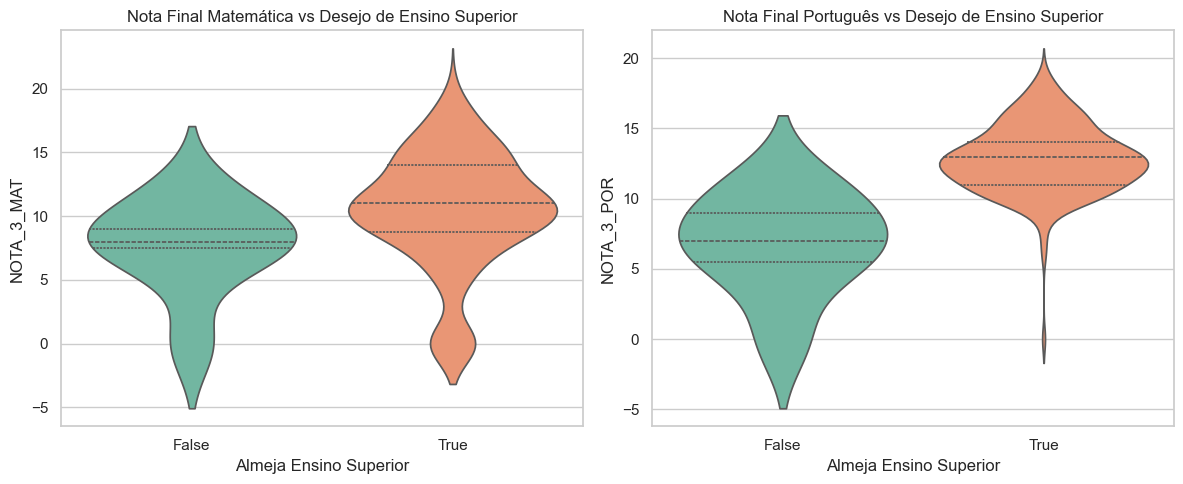


Matemática: Almeja Superior → média=10.45, mediana=11.0 (n=200)
Matemática: NÃO almeja     → média=7.57, mediana=8.0 (n=7)
  Diferença de médias: 2.87 pontos

Português: Almeja Superior → média=12.81, mediana=13.0 (n=200)
Português: NÃO almeja     → média=6.71, mediana=7.0 (n=7)
  Diferença de médias: 6.10 pontos


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(x='ALMEJA_ENSINO_SUPERIOR', y='NOTA_3_MAT', data=df_eda, ax=axes[0], palette='Set2', inner='quartile')
axes[0].set_title('Nota Final Matemática vs Desejo de Ensino Superior')
axes[0].set_xlabel('Almeja Ensino Superior')

sns.violinplot(x='ALMEJA_ENSINO_SUPERIOR', y='NOTA_3_POR', data=df_eda, ax=axes[1], palette='Set2', inner='quartile')
axes[1].set_title('Nota Final Português vs Desejo de Ensino Superior')
axes[1].set_xlabel('Almeja Ensino Superior')

plt.tight_layout()
plt.show()

# Estatísticas comparativas
for disc, col in [('Matemática', 'NOTA_3_MAT'), ('Português', 'NOTA_3_POR')]:
    sim = df_eda[df_eda['ALMEJA_ENSINO_SUPERIOR'] == True][col]
    nao = df_eda[df_eda['ALMEJA_ENSINO_SUPERIOR'] == False][col]
    print(f"\n{disc}: Almeja Superior → média={sim.mean():.2f}, mediana={sim.median():.1f} (n={len(sim)})")
    print(f"{disc}: NÃO almeja     → média={nao.mean():.2f}, mediana={nao.median():.1f} (n={len(nao)})")
    print(f"  Diferença de médias: {sim.mean() - nao.mean():.2f} pontos")

### Q3: Aulas extras pagas vs tempo de estudo individual — qual pesa mais?

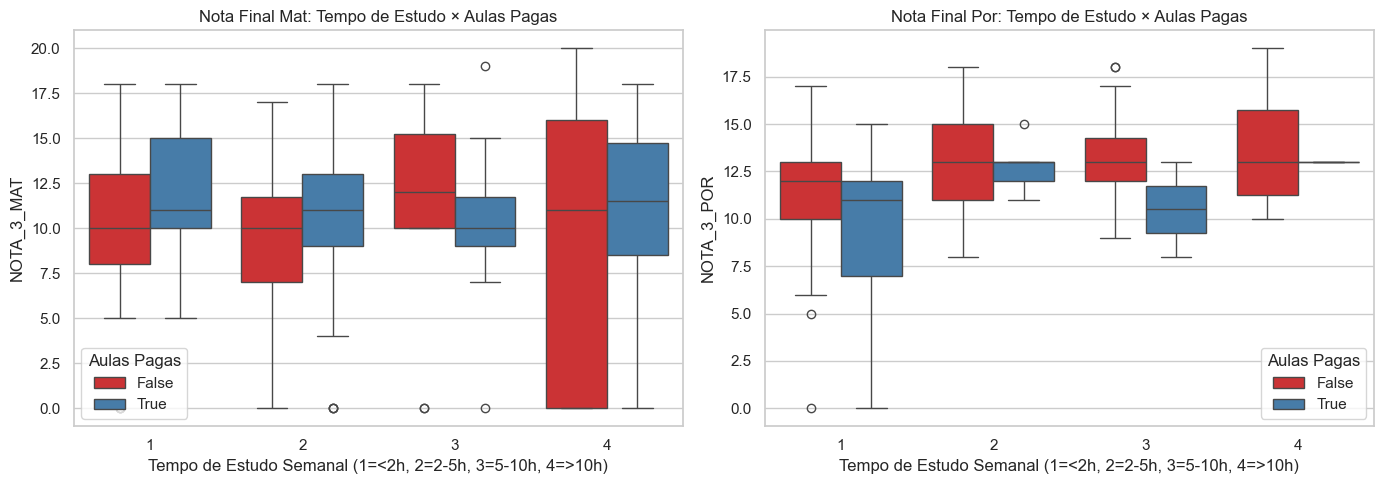


Correlações com Nota Final:
  Tempo de Estudo → Mat: r=0.014
  Tempo de Estudo → Por: r=0.289
  Aulas Pagas Mat: Sim=10.83 | Não=9.89 | Δ=0.94
  Aulas Pagas Por: Sim=11.00 | Não=12.72 | Δ=-1.72


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matemática: comparar aulas pagas vs tempo de estudo
sns.boxplot(x='TEMPO_ESTUDO_SEMANAL', y='NOTA_3_MAT', hue='AULAS_PAGAS_MAT',
            data=df_eda, ax=axes[0], palette='Set1')
axes[0].set_title('Nota Final Mat: Tempo de Estudo × Aulas Pagas')
axes[0].set_xlabel('Tempo de Estudo Semanal (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)')
axes[0].legend(title='Aulas Pagas')

# Português
sns.boxplot(x='TEMPO_ESTUDO_SEMANAL', y='NOTA_3_POR', hue='AULAS_PAGAS_POR',
            data=df_eda, ax=axes[1], palette='Set1')
axes[1].set_title('Nota Final Por: Tempo de Estudo × Aulas Pagas')
axes[1].set_xlabel('Tempo de Estudo Semanal (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)')
axes[1].legend(title='Aulas Pagas')

plt.tight_layout()
plt.show()

# Correlações
print("\nCorrelações com Nota Final:")
print(f"  Tempo de Estudo → Mat: r={df_eda['TEMPO_ESTUDO_SEMANAL'].corr(df_eda['NOTA_3_MAT']):.3f}")
print(f"  Tempo de Estudo → Por: r={df_eda['TEMPO_ESTUDO_SEMANAL'].corr(df_eda['NOTA_3_POR']):.3f}")

# Média por grupo aulas pagas
for disc, col_nota, col_pago in [('Mat', 'NOTA_3_MAT', 'AULAS_PAGAS_MAT'), ('Por', 'NOTA_3_POR', 'AULAS_PAGAS_POR')]:
    pago = df_eda[df_eda[col_pago] == True][col_nota].mean()
    nao_pago = df_eda[df_eda[col_pago] == False][col_nota].mean()
    print(f"  Aulas Pagas {disc}: Sim={pago:.2f} | Não={nao_pago:.2f} | Δ={pago-nao_pago:.2f}")

### Q4: É possível identificar alunos com alto risco de reprovação usando dados socioeconômicos + nota do 1º período?

Taxa de reprovação Matemática: 33.8%
Taxa de reprovação Português:  6.3%


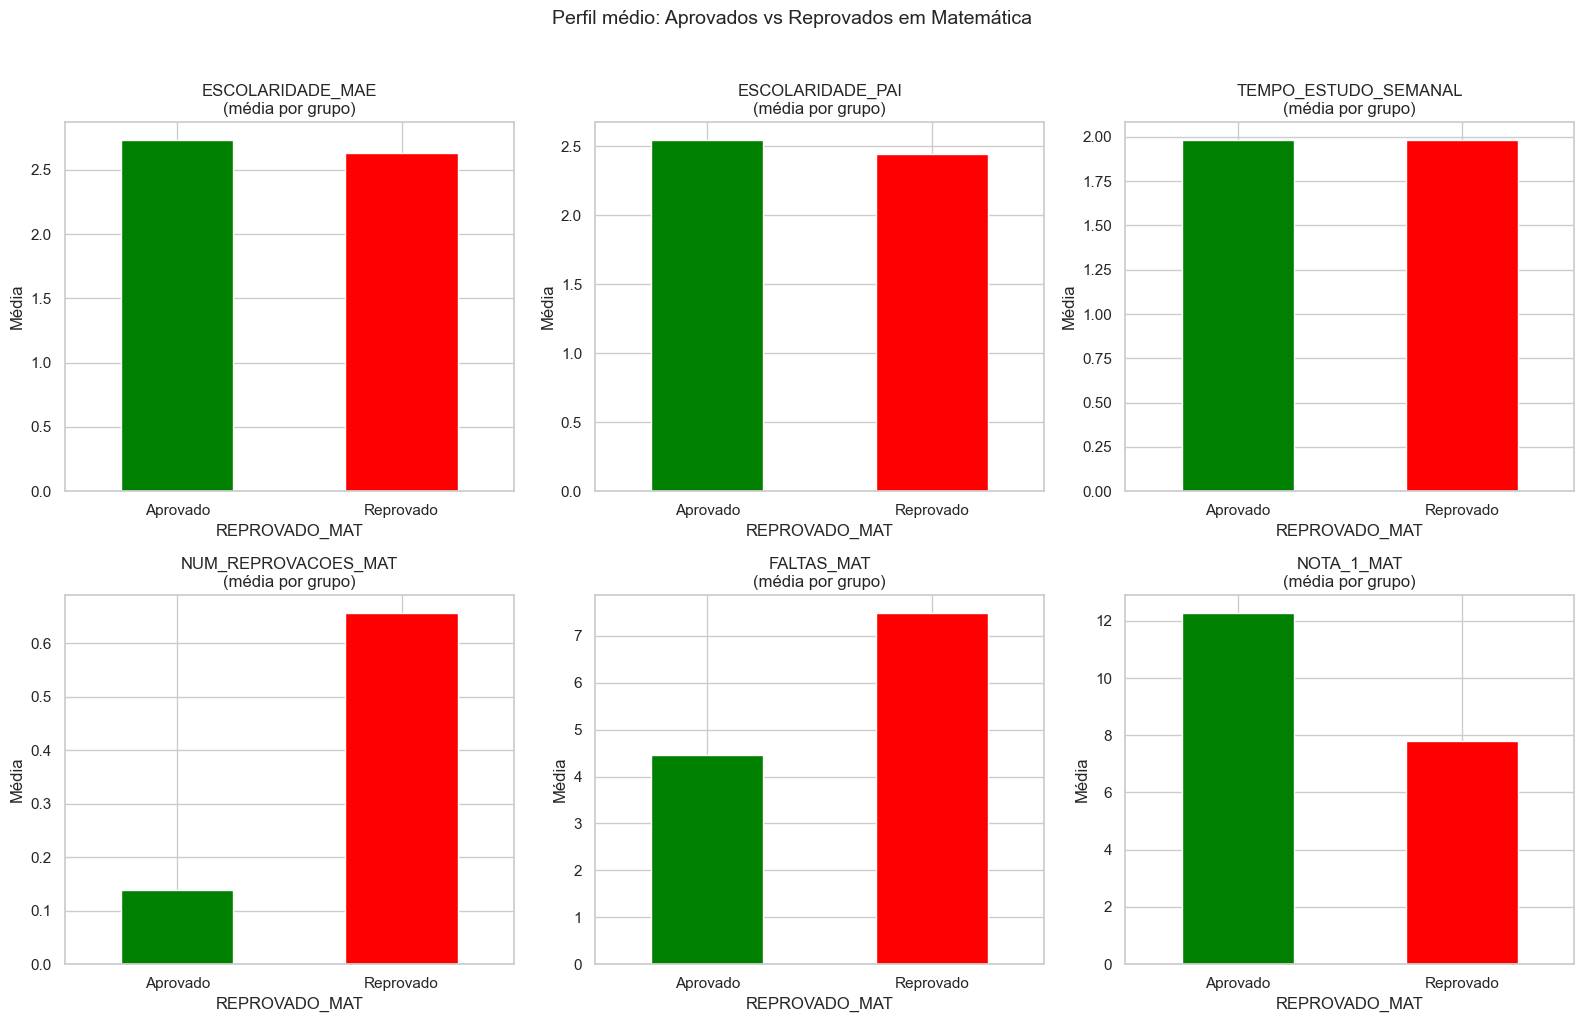

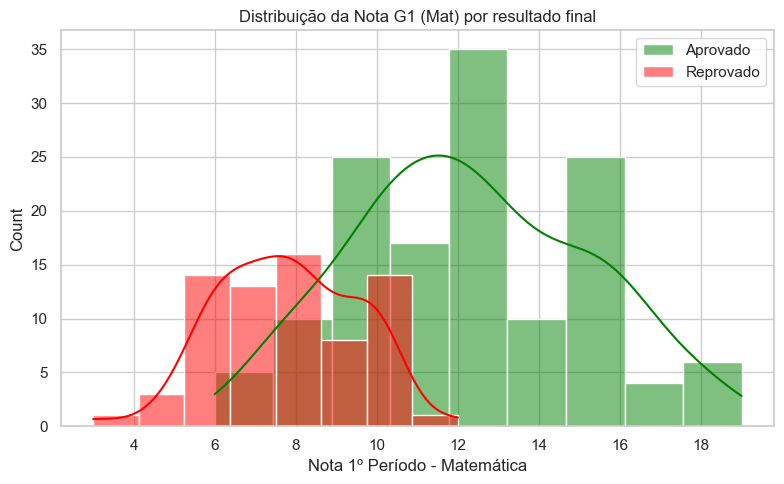

In [11]:
# Definir reprovação: nota final < 10 (escala 0-20)
df_eda['REPROVADO_MAT'] = df_eda['NOTA_3_MAT'] < 10
df_eda['REPROVADO_POR'] = df_eda['NOTA_3_POR'] < 10

print(f"Taxa de reprovação Matemática: {df_eda['REPROVADO_MAT'].mean()*100:.1f}%")
print(f"Taxa de reprovação Português:  {df_eda['REPROVADO_POR'].mean()*100:.1f}%")

# Variáveis socioeconômicas + G1 como preditores
vars_socio = ['ESCOLARIDADE_MAE', 'ESCOLARIDADE_PAI', 'TEMPO_ESTUDO_SEMANAL',
              'NUM_REPROVACOES_MAT', 'FALTAS_MAT', 'NOTA_1_MAT']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, var in enumerate(vars_socio):
    ax = axes[i // 3, i % 3]
    df_eda.groupby('REPROVADO_MAT')[var].mean().plot(kind='bar', ax=ax, color=['green', 'red'])
    ax.set_title(f'{var}\n(média por grupo)')
    ax.set_xticklabels(['Aprovado', 'Reprovado'], rotation=0)
    ax.set_ylabel('Média')

plt.suptitle('Perfil médio: Aprovados vs Reprovados em Matemática', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Nota G1 como preditor de reprovação
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_eda[df_eda['REPROVADO_MAT']==False]['NOTA_1_MAT'], kde=True, color='green', label='Aprovado', alpha=0.5, ax=ax)
sns.histplot(df_eda[df_eda['REPROVADO_MAT']==True]['NOTA_1_MAT'], kde=True, color='red', label='Reprovado', alpha=0.5, ax=ax)
ax.set_title('Distribuição da Nota G1 (Mat) por resultado final')
ax.set_xlabel('Nota 1º Período - Matemática')
ax.legend()
plt.tight_layout()
plt.show()

### Q5: Qual é o peso do nível de escolaridade dos pais na formação dos perfis de alunos de alto e baixo desempenho?

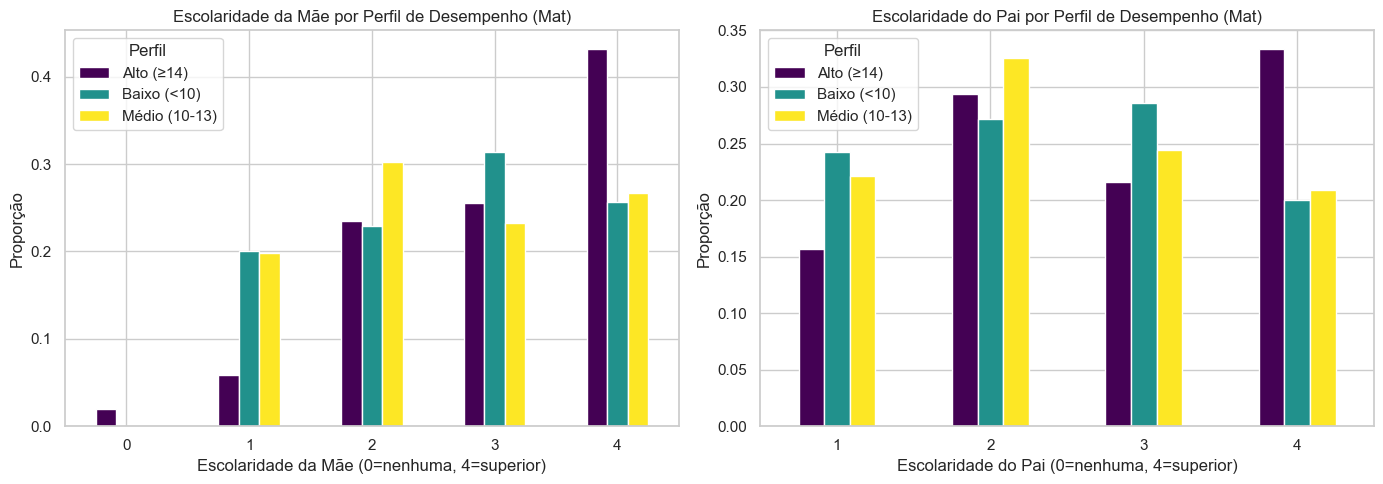


Média de escolaridade dos pais por perfil de desempenho (Matemática):
               ESCOLARIDADE_MAE  ESCOLARIDADE_PAI  N_ALUNOS
PERFIL_MAT                                                 
Alto (≥14)                 3.02              2.73        51
Baixo (<10)                2.63              2.44        70
Médio (10-13)              2.57              2.44        86


In [12]:
# Criar categorias de desempenho
def categorizar_desempenho(nota):
    if nota >= 14:
        return 'Alto (≥14)'
    elif nota >= 10:
        return 'Médio (10-13)'
    else:
        return 'Baixo (<10)'

df_eda['PERFIL_MAT'] = df_eda['NOTA_3_MAT'].apply(categorizar_desempenho)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escolaridade da mãe por perfil
df_eda.groupby('PERFIL_MAT')['ESCOLARIDADE_MAE'].value_counts(normalize=True).unstack(level=0).plot(
    kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Escolaridade da Mãe por Perfil de Desempenho (Mat)')
axes[0].set_xlabel('Escolaridade da Mãe (0=nenhuma, 4=superior)')
axes[0].set_ylabel('Proporção')
axes[0].legend(title='Perfil')
axes[0].tick_params(axis='x', rotation=0)

# Escolaridade do pai por perfil
df_eda.groupby('PERFIL_MAT')['ESCOLARIDADE_PAI'].value_counts(normalize=True).unstack(level=0).plot(
    kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Escolaridade do Pai por Perfil de Desempenho (Mat)')
axes[1].set_xlabel('Escolaridade do Pai (0=nenhuma, 4=superior)')
axes[1].set_ylabel('Proporção')
axes[1].legend(title='Perfil')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Tabela resumo
print("\nMédia de escolaridade dos pais por perfil de desempenho (Matemática):")
resumo = df_eda.groupby('PERFIL_MAT')[['ESCOLARIDADE_MAE', 'ESCOLARIDADE_PAI']].mean()
resumo['N_ALUNOS'] = df_eda.groupby('PERFIL_MAT').size()
print(resumo.round(2))